# Relighting video — directional light sweeping azimuth -45° → +45°

Relights a scene with an **SH-approximated directional light** whose azimuth interpolates
from `AZ_FROM` to `AZ_TO`, and writes a video. Two sources of intrinsics:

* **GT** — the albedo / metallic / roughness from a `3dfront-batch/datasets/<view>/<dataset>/`
  dir (the GT datasets built by `batch_dataset_decomposition.ipynb`).
* **EST** — the recovered `albedo_est|albedo_scaled`, `metallic_est`, `roughness_est` from a
  `run_decomposition.py` run dir.

Geometry (normals + mask) always comes from the dataset: the decomposition never estimates
normals, so GT and EST are relit through **identical geometry** and differ only in the
intrinsics. That is what makes the error map meaningful.

### Conventions
`make_proxy_geometry` puts the camera at `(0, 0, +cam_dist)` looking down −Z, with +Y up.
So azimuth rotates the light around the **Y (up)** axis, `az=0` meaning "from the camera":

```
d(az, el) = [cos(el)·sin(az),  sin(el),  cos(el)·cos(az)]
```

### On the albedo scale ambiguity
Albedo and lighting trade off by a global scale, so it is unobservable from the images. The
run stores both `albedo_est` (raw) and `albedo_scaled` (fitted to the GT albedo scale). The
quantification cell reports **both**, so you can see how much of the relighting error is
just that global scale versus real structural error. (`relight_rmse` in `metrics.json` uses
the **raw** albedo.)


In [1]:
import sys, os, json, math, shutil
from pathlib import Path
import numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image

REPO = Path('.').resolve()
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
os.environ.setdefault('WANDB_MODE', 'disabled')

from raw_optimizer.dfront_ct import load_scene, make_proxy_geometry, LIGHT_COLOR, LIGHT_INTENSITY
from raw_renderer_gpu import shade_ct_sh, SHLighting
from raw_renderer_gpu.rasterizer import _get_ggx_sh_lut

# ── config ────────────────────────────────────────────────────────────────────
DATASETS_ROOT = Path(r"E:\DLVC-backups\260720_results\3dfront-batch\datasets")
RUNS_ROOT     = Path(r"E:\DLVC-backups\260720_results\3dfront-batch\runs")
OUT_ROOT      = Path("results") / "relight_video"

RUN_NAME   = None          # a dir under RUNS_ROOT; None = first one found
DATASET    = "ct-ct_sh-frOn_env"   # used when rendering GT standalone / to resolve a run
VIEW       = None          # view key for the GT-only video; None = first with DATASET

AZ_FROM, AZ_TO = -45.0, 45.0
N_FRAMES   = 61            # frames across the sweep
ELEV_DEG   = 30.0          # light elevation above the horizon
FPS        = 20
PING_PONG  = True          # play the sweep forward then back (nicer loop)

GT_DOWNSAMPLE = 4          # for the GT-only video (1 = full res). Comparison cells use
                           # the run's own resolution so GT and EST always match.
DIFFUSE_FRESNEL = True     # must match how the data was generated
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DT = torch.float32

OUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"datasets: {DATASETS_ROOT}\nruns    : {RUNS_ROOT}\nout     : {OUT_ROOT}\ndevice  : {DEVICE}")


c:\Users\felix\miniconda3\envs\torch311\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


datasets: E:\DLVC-backups\260720_results\3dfront-batch\datasets
runs    : E:\DLVC-backups\260720_results\3dfront-batch\runs
out     : results\relight_video
device  : cuda


## Helpers — directional SH, intrinsics loading, renderer, video writing

In [2]:
def dir_sh(az_deg, elev_deg=ELEV_DEG, color=LIGHT_COLOR, intensity=LIGHT_INTENSITY):
    """SH2 coefficients (9,3) for a directional light at (azimuth, elevation).
    az=0 -> from the camera (+Z); +az swings to +X; +elev raises it toward +Y."""
    az, el = math.radians(az_deg), math.radians(elev_deg)
    d = np.array([math.cos(el) * math.sin(az),
                  math.sin(el),
                  math.cos(el) * math.cos(az)], np.float32)
    d /= np.linalg.norm(d)
    return SHLighting.directional(d, np.asarray(color, np.float32), intensity).coeffs


def _stride(a, ds):
    return np.ascontiguousarray(a[::ds, ::ds]) if ds > 1 else a


class Relighter:
    """Fixed geometry + LUT; relight any (albedo, metallic, roughness) under any SH."""

    def __init__(self, normals_np, mask_np, device=DEVICE, dtype=DT):
        self.H, self.W = normals_np.shape[:2]
        self.mask_np = mask_np
        n, f, m, cam = make_proxy_geometry(normals_np, mask_np, 60.0, 2.0, device, dtype)
        self.fm = m.reshape(-1)
        self.N = n.reshape(-1, 3)[self.fm]
        self.V = torch.nn.functional.normalize(cam[None] - f.reshape(-1, 3)[self.fm], dim=-1)
        self.lut = _get_ggx_sh_lut(device, n_bands=3).to(dtype)
        self.device, self.dtype = device, dtype

    def _m(self, a, c):
        return torch.from_numpy(np.ascontiguousarray(a)).to(self.device, self.dtype)\
                    .reshape(-1, c)[self.fm]

    def render(self, intr, sh):
        """-> (H,W,3) float32, background 0."""
        with torch.no_grad():
            px = shade_ct_sh(self.V, self.N, self._m(intr['albedo'], 3),
                             torch.from_numpy(np.asarray(sh, np.float32)).to(self.device, self.dtype),
                             self._m(intr['metallic'], 1), self._m(intr['roughness'], 1),
                             lut=self.lut, diffuse_fresnel=DIFFUSE_FRESNEL)
        out = np.zeros((self.H * self.W, 3), np.float32)
        out[self.fm.cpu().numpy()] = px.float().cpu().numpy()
        return out.reshape(self.H, self.W, 3)


def load_gt(dataset_dir, ds=1):
    """GT intrinsics + geometry from a dataset dir, strided by `ds`."""
    sc = load_scene(Path(dataset_dir), gt_npy=True)
    return dict(albedo=_stride(sc['albedo_np'], ds), metallic=_stride(sc['metallic_np'], ds),
                roughness=_stride(sc['roughness_np'], ds),
                normals=_stride(sc['normals_np'], ds), mask=_stride(sc['mask_np'], ds))


def resolve_dataset(run_dir, datasets_root=DATASETS_ROOT):
    """The dataset a run came from: metrics.json['scene'] if it resolves locally,
    else parsed from the run dir name '<view>__<dataset>__<rest>'."""
    run_dir = Path(run_dir)
    m = json.loads((run_dir / 'metrics.json').read_text())
    p = Path(m.get('scene', ''))
    if p.exists():
        return p
    parts = run_dir.name.split('__')
    if len(parts) >= 2:
        cand = Path(datasets_root) / parts[0] / parts[1]
        if cand.exists():
            return cand
    raise FileNotFoundError(f"cannot resolve the source dataset for {run_dir.name}; "
                            f"metrics scene='{m.get('scene')}' not found and "
                            f"'{datasets_root / parts[0] / parts[1] if len(parts)>=2 else '?'}' missing")


def load_est(run_dir, scaled=True):
    """Estimated intrinsics + the matching GT (strided to the run's resolution)."""
    run_dir = Path(run_dir)
    alb_f = 'albedo_scaled.npy' if scaled else 'albedo_est.npy'
    est = dict(albedo=np.load(run_dir / alb_f).astype(np.float32),
               metallic=np.load(run_dir / 'metallic_est.npy').astype(np.float32),
               roughness=np.load(run_dir / 'roughness_est.npy').astype(np.float32))
    ds_dir = resolve_dataset(run_dir)
    sc = load_scene(ds_dir, gt_npy=True)
    ds = max(1, sc['normals_np'].shape[0] // est['albedo'].shape[0])   # decompose downsample
    gt = load_gt(ds_dir, ds)
    if gt['albedo'].shape[:2] != est['albedo'].shape[:2]:
        raise ValueError(f"resolution mismatch: GT {gt['albedo'].shape[:2]} vs "
                         f"EST {est['albedo'].shape[:2]} (inferred ds={ds})")
    return est, gt, ds_dir, ds


# ── tonemapping + video ───────────────────────────────────────────────────────
def make_tonemap(frames, pct=99.5):
    """One exposure for the whole sweep so the video doesn't flicker."""
    s = np.percentile(np.stack(frames), pct)
    s = float(s) if s > 1e-8 else 1.0
    return lambda im: (np.clip(im / s, 0, 1) ** (1 / 2.2) * 255).astype(np.uint8)


def write_video(frames_u8, stem, fps=FPS, ping_pong=PING_PONG):
    """mp4 if an ffmpeg backend exists, else animated GIF. Always writes PNG frames."""
    seq = list(frames_u8) + list(frames_u8)[-2:0:-1] if ping_pong else list(frames_u8)
    fdir = Path(f"{stem}_frames"); fdir.mkdir(parents=True, exist_ok=True)
    for i, f in enumerate(frames_u8):
        Image.fromarray(f).save(fdir / f"frame_{i:03d}.png")
    out = None
    try:
        import imageio.v2 as iio
        try:
            iio.mimsave(f"{stem}.mp4", seq, fps=fps, macro_block_size=1)
            out = f"{stem}.mp4"
        except Exception:
            iio.mimsave(f"{stem}.gif", seq, duration=1 / fps, loop=0)
            out = f"{stem}.gif"
    except ImportError:
        ims = [Image.fromarray(f) for f in seq]
        ims[0].save(f"{stem}.gif", save_all=True, append_images=ims[1:],
                    duration=int(1000 / fps), loop=0)
        out = f"{stem}.gif"
    print(f"  {len(seq)} frames -> {out}   (stills in {fdir.name}/)")
    return out


AZIMUTHS = np.linspace(AZ_FROM, AZ_TO, N_FRAMES)
print(f"sweep: {AZ_FROM}° -> {AZ_TO}° in {N_FRAMES} frames, elevation {ELEV_DEG}°")
print(f"check: az=0 direction = {np.round(dir_sh(0)[0], 3)} (DC term, should be > 0)")


sweep: -45.0° -> 45.0° in 61 frames, elevation 30.0°
check: az=0 direction = [0.564 0.508 0.451] (DC term, should be > 0)


## 1. GT video — relight the ground-truth intrinsics

Standalone sweep on a dataset dir, at `GT_DOWNSAMPLE`.

GT: 1f19c3ef_v2/ct-ct_sh-frOn_env  ->  128^2 (16,384 masked px)
  120 frames -> results\relight_video\gt_1f19c3ef_v2_ct-ct_sh-frOn_env.mp4   (stills in gt_1f19c3ef_v2_ct-ct_sh-frOn_env_frames/)


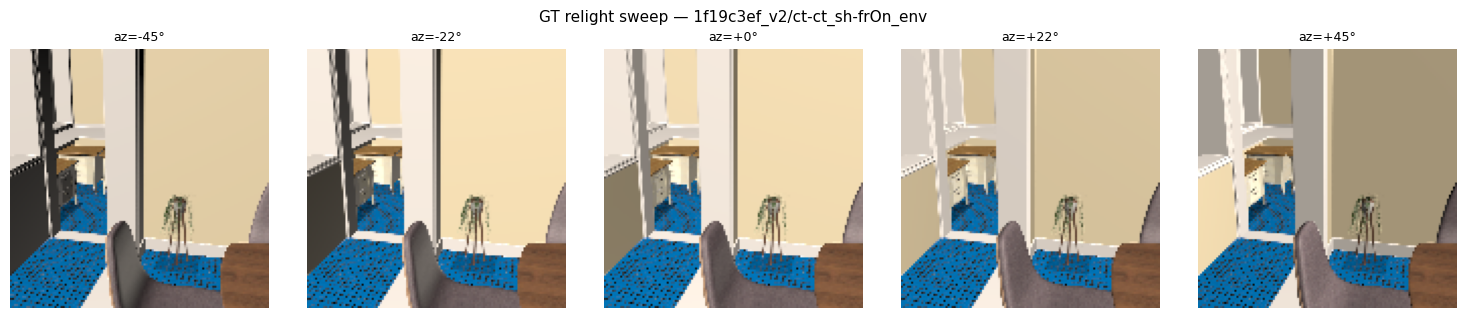

In [3]:
def pick_view(datasets_root, dataset, view=None):
    root = Path(datasets_root)
    for vd in sorted(p for p in root.iterdir() if p.is_dir()):
        if view and vd.name != view:
            continue
        if (vd / dataset / 'config.json').exists():
            return vd.name, vd / dataset
    raise FileNotFoundError(f"no view with '{dataset}' under {root}")


gt_view, gt_dir = pick_view(DATASETS_ROOT, DATASET, VIEW)
gt = load_gt(gt_dir, GT_DOWNSAMPLE)
rel_gt = Relighter(gt['normals'], gt['mask'])
print(f"GT: {gt_view}/{DATASET}  ->  {gt['albedo'].shape[0]}^2 "
      f"({int(gt['mask'].sum()):,} masked px)")

frames = [rel_gt.render(gt, dir_sh(az)) for az in AZIMUTHS]
tm = make_tonemap(frames)
write_video([tm(f) for f in frames], str(OUT_ROOT / f"gt_{gt_view}_{DATASET}"))

fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for a, i in zip(ax, np.linspace(0, len(frames) - 1, 5).astype(int)):
    a.imshow(tm(frames[i])); a.set_title(f"az={AZIMUTHS[i]:+.0f}°", fontsize=9); a.axis('off')
fig.suptitle(f"GT relight sweep — {gt_view}/{DATASET}", fontsize=11)
plt.tight_layout(); plt.show()


## 2. EST video — relight the recovered intrinsics

Uses a `run_decomposition.py` run dir. The GT is strided to the run's own resolution so
the two are directly comparable.

In [ ]:
def pick_run(runs_root, name=None):
    root = Path(runs_root)
    if not root.exists():
        raise FileNotFoundError(f"RUNS_ROOT does not exist: {root}")
    if name:
        r = root / name
        if not (r / 'metrics.json').exists():
            raise FileNotFoundError(f"no metrics.json in {r}")
        return r
    cand = sorted(p for p in root.iterdir() if p.is_dir() and (p / 'metrics.json').exists()
                  and (p / 'albedo_est.npy').exists())
    if not cand:
        raise FileNotFoundError(f"no completed runs under {root}")
    return cand[0]


run_dir = pick_run(RUNS_ROOT, RUN_NAME)
est, gt_m, src_ds, run_ds = load_est(run_dir, scaled=True)
rel = Relighter(gt_m['normals'], gt_m['mask'])       # geometry from GT (normals aren't estimated)
print(f"run    : {run_dir.name}")
print(f"source : {src_ds}   (decomposed at ds={run_ds} -> {est['albedo'].shape[0]}^2)")

est_frames = [rel.render(est, dir_sh(az)) for az in AZIMUTHS]
gtm_frames = [rel.render(gt_m, dir_sh(az)) for az in AZIMUTHS]
tm_c = make_tonemap(gtm_frames)                       # shared exposure: GT sets it
write_video([tm_c(f) for f in est_frames], str(OUT_ROOT / f"est_{run_dir.name}"))

fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for a, i in zip(ax, np.linspace(0, len(est_frames) - 1, 5).astype(int)):
    a.imshow(tm_c(est_frames[i])); a.set_title(f"az={AZIMUTHS[i]:+.0f}°", fontsize=9); a.axis('off')
fig.suptitle(f"EST relight sweep — {run_dir.name}", fontsize=10)
plt.tight_layout(); plt.show()


## 3. Side-by-side video: GT | EST | error

One video with the three panels, shared exposure and a fixed error scale across frames.

In [ ]:
err_frames = [np.abs(g - e).mean(-1) for g, e in zip(gtm_frames, est_frames)]
EMAX = float(np.percentile(np.stack(err_frames), 99.5)) or 1.0
cmap = plt.get_cmap('inferno')
mask2 = gt_m['mask']

def err_rgb(e):
    rgb = (cmap(np.clip(e / EMAX, 0, 1))[..., :3] * 255).astype(np.uint8)
    rgb[~mask2] = 0
    return rgb

def label(img, txt):
    from PIL import ImageDraw
    im = Image.fromarray(img); ImageDraw.Draw(im).text((3, 2), txt, fill=(255, 255, 255))
    return np.asarray(im)

combo = []
for g, e, er, az in zip(gtm_frames, est_frames, err_frames, AZIMUTHS):
    combo.append(np.concatenate([label(tm_c(g), 'GT'), label(tm_c(e), 'EST'),
                                 label(err_rgb(er), f'|err| az={az:+.0f}')], axis=1))
write_video(combo, str(OUT_ROOT / f"compare_{run_dir.name}"))
print(f"error colour scale: 0 .. {EMAX:.4f} (99.5th pct over the sweep)")

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
mid = len(AZIMUTHS) // 2
for a, im, t in zip(ax, [tm_c(gtm_frames[mid]), tm_c(est_frames[mid]), err_frames[mid]],
                    ['GT', 'EST', '|GT-EST|']):
    h = a.imshow(im, cmap='inferno' if t.startswith('|') else None,
                 vmin=0 if t.startswith('|') else None, vmax=EMAX if t.startswith('|') else None)
    a.set_title(f"{t}  (az={AZIMUTHS[mid]:+.0f}°)", fontsize=10); a.axis('off')
    if t.startswith('|'): plt.colorbar(h, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()


## 4. Relighting GT vs estimate — error maps + quantification

Panels at several azimuths, then the error across the whole sweep. Reported for **both**
albedo variants:

* **raw** (`albedo_est`) — what `metrics.json`'s `relight_rmse` uses; includes the global
  albedo/lighting scale ambiguity.
* **scaled** (`albedo_scaled`) — scale fitted to GT, so what remains is structural error.

A large raw-vs-scaled gap means the error is dominated by an unobservable global scale, not
by a genuinely wrong decomposition.

In [ ]:
N_PANELS = 5
idx = np.linspace(0, len(AZIMUTHS) - 1, N_PANELS).astype(int)
fig, axes = plt.subplots(3, N_PANELS, figsize=(3.1 * N_PANELS, 9))
for c, i in enumerate(idx):
    for r, (im, t, cm) in enumerate([(tm_c(gtm_frames[i]), 'GT', None),
                                     (tm_c(est_frames[i]), 'EST', None),
                                     (err_frames[i], '|err|', 'inferno')]):
        a = axes[r, c]
        h = a.imshow(im, cmap=cm, vmin=0 if cm else None, vmax=EMAX if cm else None)
        a.axis('off')
        if r == 0: a.set_title(f"az={AZIMUTHS[i]:+.0f}°", fontsize=9)
        if c == 0: a.text(-0.08, 0.5, t, transform=a.transAxes, rotation=90,
                          va='center', ha='center', fontsize=10)
        if cm and c == N_PANELS - 1: plt.colorbar(h, ax=a, fraction=0.046)
fig.suptitle(f"relighting: GT vs estimate — {run_dir.name}", fontsize=11)
plt.tight_layout(); plt.show()

# ── quantification over the sweep, raw vs scaled albedo ───────────────────────
import pandas as pd
mflat = gt_m['mask']
def sweep_err(est_i):
    fr = [rel.render(est_i, dir_sh(az)) for az in AZIMUTHS]
    rm, ma = [], []
    for g, e in zip(gtm_frames, fr):
        d = (g - e)[mflat]
        rm.append(float(np.sqrt((d ** 2).mean()))); ma.append(float(np.abs(d).mean()))
    return np.array(rm), np.array(ma)

est_raw, _, _, _ = load_est(run_dir, scaled=False)
res = {}
for lbl, ei in (('raw (albedo_est)', est_raw), ('scaled (albedo_scaled)', est)):
    rm, ma = sweep_err(ei)
    res[lbl] = dict(rmse_mean=rm.mean(), rmse_std=rm.std(), rmse_min=rm.min(),
                    rmse_max=rm.max(), mae_mean=ma.mean(), _rm=rm)
tbl = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not kk.startswith('_')}
                    for k, v in res.items()}).T
print(f"relighting error over {len(AZIMUTHS)} azimuths "
      f"({AZ_FROM:+.0f}° to {AZ_TO:+.0f}°, elev {ELEV_DEG}°), masked pixels only:\n")
print(tbl.round(5).to_string())

m = json.loads((run_dir / 'metrics.json').read_text())
print(f"\nfor reference, this run's own held-out metric (its GT env lights, not this "
      f"directional sweep): relight_rmse={m.get('relight_rmse'):.5f}")
gap = res['raw (albedo_est)']['rmse_mean'] / max(res['scaled (albedo_scaled)']['rmse_mean'], 1e-12)
print(f"raw / scaled RMSE ratio = {gap:.2f}x  -> "
      + ("most of the raw error is the global albedo scale (unobservable)"
         if gap > 1.5 else "scale is not the dominant error; it is structural"))

fig, ax = plt.subplots(figsize=(7.5, 4))
for lbl, v in res.items():
    ax.plot(AZIMUTHS, v['_rm'], lw=1.8, label=f"{lbl}  (mean {v['rmse_mean']:.4f})")
ax.set_xlabel('light azimuth (deg)'); ax.set_ylabel('relight RMSE vs GT')
ax.set_title('relighting error across the azimuth sweep', fontsize=10)
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Batch: sweep every run

Runs sections 2–4's quantification for every run under `RUNS_ROOT` and writes a CSV, so you
can rank strategies by how well their intrinsics relight under a *novel* directional light —
which is a stronger test than the held-out env relight (different lighting family).

In [ ]:
BATCH = False          # set True to process every run (slow)
if BATCH:
    rows = []
    runs = sorted(p for p in RUNS_ROOT.iterdir()
                  if p.is_dir() and (p / 'metrics.json').exists()
                  and (p / 'albedo_est.npy').exists())
    print(f"{len(runs)} run(s)")
    for i, rd in enumerate(runs, 1):
        try:
            e_s, g, _, ds = load_est(rd, scaled=True)
            e_r, _, _, _ = load_est(rd, scaled=False)
            rl = Relighter(g['normals'], g['mask'])
            gfr = [rl.render(g, dir_sh(az)) for az in AZIMUTHS]
            out = {}
            for lbl, ei in (('raw', e_r), ('scaled', e_s)):
                er = [float(np.sqrt((((gg - rl.render(ei, dir_sh(az)))[g['mask']]) ** 2).mean()))
                      for gg, az in zip(gfr, AZIMUTHS)]
                out[f'sweep_rmse_{lbl}'] = float(np.mean(er))
            mm = json.loads((rd / 'metrics.json').read_text())
            rows.append(dict(run=rd.name, downsample=ds, **out,
                             env_relight_rmse=mm.get('relight_rmse'),
                             albedo_rmse=mm.get('albedo_rmse')))
            print(f"[{i}/{len(runs)}] {rd.name}: raw={out['sweep_rmse_raw']:.4f} "
                  f"scaled={out['sweep_rmse_scaled']:.4f}", flush=True)
        except Exception as ex:
            print(f"[{i}/{len(runs)}] {rd.name}: FAILED {type(ex).__name__}: {ex}")
    df = pd.DataFrame(rows).sort_values('sweep_rmse_scaled')
    df.to_csv(OUT_ROOT / 'relight_sweep_summary.csv', index=False)
    print(df.round(5).to_string(index=False))
    print(f"\n-> {OUT_ROOT / 'relight_sweep_summary.csv'}")
else:
    print("BATCH = False — set it True to sweep every run under RUNS_ROOT")
